In [4]:
import cv2
import numpy as np  
import easyocr
import matplotlib.pyplot as plt


In [17]:
img = cv2.imread('ocr_text2.webp')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

denoised = cv2.fastNlMeansDenoising(gray, None, 30, 7, 21)

thresh = cv2.adaptiveThreshold(
    denoised, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

kernel = np.ones((1, 1), np.uint8)
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)


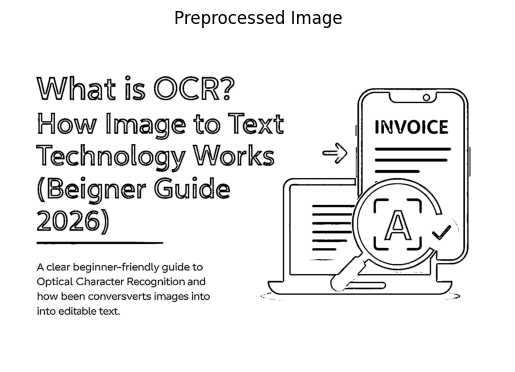

In [18]:
plt.imshow(cleaned, cmap='gray')
plt.title('Preprocessed Image')
plt.axis('off')
plt.show()

In [19]:
reader = easyocr.Reader(['en'])

results = reader.readtext(cleaned)

for (bbox, text, prob) in results:
    print(f"{text} ({prob:.2f})")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


What is OCR? (1.00)
How Image to Text (0.81)
INVOICE (1.00)
Technology Works (1.00)
(Beigner Guide (0.70)
2026) (1.00)
A clear (1.00)
beginner-friendly guide to (0.97)
Optical Character Recognition and (1.00)
how been conversverts images into (0.83)
into editable text. (0.89)
A (1.00)


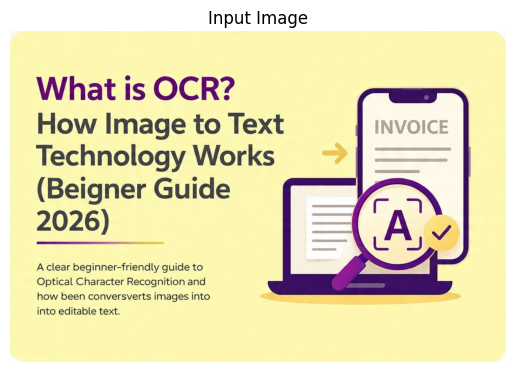

Extracted Text:

What is OCR?

How Image to Text tae
Technology Works

(Beigner Guide _
2026) |

2026) CAly
A clear beginner-friendly guide to

Optical Character Recognition and

how been conversverts images into

into editable text.



In [20]:
import cv2
import pytesseract
import matplotlib.pyplot as plt

# IMPORTANT: Set Tesseract path (change if needed)
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Load image
img = cv2.imread("ocr_text2.webp")

# Convert to RGB (Tesseract expects RGB)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(img_rgb)
plt.title("Input Image")
plt.axis('off')
plt.show()

# --- STEP 1: Grayscale ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- STEP 2: Threshold (clean text separation) ---
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

# --- STEP 3: OCR ---
custom_config = r'--oem 3 --psm 6'
text = pytesseract.image_to_string(thresh, config=custom_config)

# --- OUTPUT ---
print("Extracted Text:\n")
print(text)